# Multi-Agente Cooperativo en Overcooked con MAPPO

**Entorno:** [Overcooked-AI](https://github.com/HumanCompatibleAI/overcooked_ai) (Berkeley HCAI)
**Algoritmo:** MAPPO (Multi-Agent PPO) **implementado a mano en PyTorch**, con *parameter sharing* y *Centralised Training, Decentralised Execution* (CTDE)
**Layout:** `forced_coordination` — los dos cocineros están físicamente separados y **obligados** a pasarse ingredientes por el mostrador del medio. Cualquier sopa entregada es prueba directa de cooperación.

---

## Objetivo del notebook
Mostrar **paso a paso cómo se implementa un sistema multiagente cooperativo**: dos agentes que aprenden, sin comunicación explícita, a coordinarse para preparar y servir sopa de cebolla.

A diferencia de las implementaciones "caja negra" basadas en frameworks (Ray RLlib, Stable-Baselines), aquí **todo el algoritmo MAPPO está escrito a la vista** en ~350 líneas:

- la red `ActorCritic` compartida,
- el cálculo de ventajas con GAE,
- la pérdida PPO con *clip*,
- el bucle de rollouts y actualización.

Solo Overcooked-AI se reutiliza como entorno (no reinventamos la cocina).


## Marco teórico — Sistemas multiagente cooperativos y MAPPO

### 1. Sistemas multiagente (MAS)
Un **Multi-Agent System** está compuesto por varios agentes autónomos que comparten un entorno y toman decisiones simultáneamente. Se clasifican según la estructura de recompensas:

| Tipo | Recompensas | Ejemplo |
|---|---|---|
| **Cooperativo** | Compartida entre todos los agentes | Overcooked, robots colaborativos |
| **Competitivo** | Suma cero | Ajedrez, Go |
| **Mixto** | Cooperación dentro de equipos, competición entre equipos | StarCraft, fútbol |

Overcooked es **puramente cooperativo**: los dos cocineros reciben la misma recompensa global (+20) cada vez que el equipo entrega una sopa, sin importar quién hizo qué.

### 2. ¿Por qué no entrenar dos PPO independientes?
Si cada agente aprendiese con un PPO propio e ignorase al otro, el entorno aparecería **no estacionario** desde su perspectiva (el otro agente cambia su política durante el entrenamiento), rompiendo las garantías de convergencia de PPO. Además no habría señal estructural para coordinarse.

### 3. MAPPO: PPO multiagente con CTDE
MAPPO ([Yu et al., 2022](https://arxiv.org/abs/2103.01955)) extiende PPO al caso multiagente con el paradigma **Centralised Training, Decentralised Execution**:

- **Crítico centralizado** (entrenamiento): la red `V(s)` ve el **estado global** (todas las observaciones concatenadas). Esto reduce la varianza de las ventajas porque el crítico ya no es ciego a lo que hace el compañero.
- **Política descentralizada** (ejecución): la red `π(a|o)` solo ve la **observación local** del agente. El agente entrenado podría desplegarse en un robot sin necesidad de comunicación.

> En nuestra implementación:
> - `ActorCritic.actor_encoder` recibe **obs local** `(5,5,26)` → 6 logits.
> - `ActorCritic.critic_encoder` recibe **obs global** `(5,5,52)` (las dos obs apiladas en el canal) → un escalar `V(s)`.

### 4. Parameter sharing
En entornos cooperativos homogéneos como Overcooked, los dos cocineros son intercambiables. Compartir **una sola red** entre ambos:

1. Reduce a la mitad los parámetros aprendibles.
2. Duplica la eficiencia muestral (cada transición entrena los dos "roles").
3. Induce coordinación implícita: ambos agentes razonan con la misma función.

> En el código: instanciamos UN solo `ActorCritic` y los dos agentes hacen forward sobre él. El gradiente que les llega proviene de las experiencias de ambos.

### 5. Pérdida PPO clip
La actualización de la política maximiza:

$$L^{CLIP}(\theta) = \mathbb{E}\!\left[\min\!\Big(r_t(\theta)\hat{A}_t,\; \text{clip}(r_t(\theta),\,1\!-\!\epsilon,\,1\!+\!\epsilon)\hat{A}_t\Big)\right]$$

donde $r_t(\theta) = \pi_\theta(a|o)/\pi_{\theta_{\text{old}}}(a|o)$. El recorte evita que un único batch desplace la política demasiado lejos.

### 6. Estructura del notebook
1. **Instalación e imports** mínimos: torch + overcooked-ai.
2. **Entorno**: wrapper minimalista sobre `OvercookedEnv` que expone obs locales, obs global y render.
3. **Visualización** del layout y el estado inicial.
4. **Red `ActorCritic`** con encoders separados para actor (local) y crítico (global).
5. **Bucle de entrenamiento**: rollouts + GAE + PPO clip update.
6. **Evaluación cuantitativa**: random vs MAPPO (sopas entregadas).
7. **Renderizado a MP4** para ver la cooperación emergente.


In [11]:
%pip -q install "numpy<2"
%pip -q install overcooked-ai
%pip -q install pygame imageio imageio-ffmpeg matplotlib

print("\n>>> Instalación completada.")


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pettingzoo 1.26.1 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; p

## 1. Imports

Lista corta y deliberada de dependencias:

- **PyTorch**: redes y optimización.
- **Overcooked-AI** (`overcooked_ai_py`): MDP, entorno episódico, visualizador.
- **matplotlib / pygame / imageio**: visualización y vídeo.

Sin Ray, sin PettingZoo, sin gymnasium. El parche `_patch_numpy2` reescribe los `np.Inf / np.NaN / np.product` que overcooked-ai (en algunas versiones) hereda de su época en numpy 1.x.


In [12]:
import os
import sys
import importlib.util

os.environ.setdefault("SDL_VIDEODRIVER", "dummy")

import numpy as np

# Shim para el proceso driver (suficiente para el código que ejecutamos aquí)
if not hasattr(np, "Inf"):     np.Inf = np.inf
if not hasattr(np, "NaN"):     np.NaN = np.nan
if not hasattr(np, "product"): np.product = np.prod


def _patch_numpy2(packages=("overcooked_ai_py",), verbose=True):
    """Reescribe en disco las APIs eliminadas en numpy 2.x dentro de los paquetes
    indicados. Idempotente (segunda ejecución no hace nada). Sin Ray ya no
    necesitamos parchear workers en otro proceso, pero overcooked-ai tiene
    código que falla al importar con numpy 2.x si no se parchea.
    """
    replacements = {
        "np.Inf":         "np.inf",
        "np.NaN":         "np.nan",
        "np.product(":    "np.prod(",
        "numpy.product(": "numpy.prod(",
    }
    total = []
    for pkg in packages:
        spec = importlib.util.find_spec(pkg)
        if spec is None or spec.origin is None:
            continue
        pkg_dir = os.path.dirname(spec.origin)
        patched = []
        for root, _, files in os.walk(pkg_dir):
            for fname in files:
                if not fname.endswith(".py"): continue
                path = os.path.join(root, fname)
                try:
                    with open(path, "r", encoding="utf-8") as f:
                        src = f.read()
                except (UnicodeDecodeError, OSError):
                    continue
                new = src
                for old, new_str in replacements.items():
                    new = new.replace(old, new_str)
                if new != src:
                    with open(path, "w", encoding="utf-8") as f:
                        f.write(new)
                    patched.append(path)
        if verbose:
            print(f"  [{pkg}] parcheados {len(patched)} archivos.")
        total.extend(patched)
        for m in list(sys.modules):
            if m == pkg or m.startswith(pkg + "."):
                del sys.modules[m]
    return total


_patch_numpy2()

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

import pygame
import matplotlib.pyplot as plt
import imageio

from overcooked_ai_py.mdp.overcooked_mdp import OvercookedGridworld
from overcooked_ai_py.mdp.overcooked_env import OvercookedEnv
from overcooked_ai_py.mdp.actions import Action
from overcooked_ai_py.visualization.state_visualizer import StateVisualizer

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nImports OK. torch={torch.__version__} | numpy={np.__version__} | device={DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


  [overcooked_ai_py] parcheados 0 archivos.

Imports OK. torch=2.10.0+cu128 | numpy=2.4.6 | device=cuda
GPU: Tesla T4


/usr/local/lib/python3.12/dist-packages/gym/envs/registration.py:542: UserWarning: WARN: Overriding environment Overcooked-v0
  logger.warn(f"Overriding environment {spec.id}")


## 2. Entorno Overcooked (wrapper minimalista)

Overcooked-AI ya implementa toda la dinámica del juego en `OvercookedGridworld` (MDP) y `OvercookedEnv`. Nuestro wrapper `TwoAgentOvercooked` se limita a **adaptar la interfaz** a algo cómodo para nuestro bucle de PyTorch:

- `reset()` → devuelve `(obs_0, obs_1)` como `np.ndarray (H, W, C)` cada uno.
- `step(a0, a1)` → devuelve `(obs_0, obs_1, reward_team, done, info)`.
- `global_obs(o0, o1)` → concatena las dos obs en el canal: `(H, W, 2*C)` para el crítico centralizado.
- `render()` → frame RGB para el MP4.

**Observación**: usamos `lossless_state_encoding_mdp`, un tensor `(5, 5, 26)` que codifica la posición de cada agente, los objetos del mapa, el estado de las ollas, etc. Es la representación "canónica" en los papers de Overcooked.

**Acciones**: las 6 acciones discretas del juego — `N, S, E, W, Stay, Interact`. La acción "Interact" es la mágica: coge/suelta objetos, mete ingredientes en la olla, sirve sopas.

**Recompensa**: `reward_team = sparse + shaped_promedio`. `sparse` es +20 al servir una sopa (compartida por los dos), `shaped` son recompensas auxiliares (poner cebolla en olla, recoger plato) que aceleran el aprendizaje sin cambiar el óptimo.


In [13]:
LAYOUT_NAME = "forced_coordination"
HORIZON     = 400
NUM_ACTIONS = 6


class TwoAgentOvercooked:
    """Wrapper mínimo sobre OvercookedEnv para 2 agentes cooperativos."""

    def __init__(self, layout_name=LAYOUT_NAME, horizon=HORIZON):
        self.layout_name = layout_name
        self.horizon     = horizon
        self.mdp         = OvercookedGridworld.from_layout_name(layout_name)
        self.base_env    = OvercookedEnv.from_mdp(self.mdp, horizon=horizon)
        self.visualizer  = StateVisualizer()
        # Inferir shape de la observación
        self.base_env.reset()
        sample = self._encode()
        self.obs_shape = tuple(sample[0].shape)            # (H, W, C)
        self.global_shape = (self.obs_shape[0],
                             self.obs_shape[1],
                             self.obs_shape[2] * 2)        # (H, W, 2C)

    # ---- helpers internos ----
    def _encode(self):
        state = self.base_env.state
        if hasattr(self.base_env, "lossless_state_encoding_mdp"):
            return self.base_env.lossless_state_encoding_mdp(state)
        return self.mdp.lossless_state_encoding(state, horizon=self.horizon)

    def _get_obs(self):
        enc = self._encode()
        o0 = np.asarray(enc[0], dtype=np.float32)
        o1 = np.asarray(enc[1], dtype=np.float32)
        return o0, o1

    # ---- API pública ----
    def reset(self):
        self.base_env.reset()
        return self._get_obs()

    def step(self, a0, a1):
        joint = (Action.INDEX_TO_ACTION[int(a0)], Action.INDEX_TO_ACTION[int(a1)])
        _, sparse_r, done, info = self.base_env.step(joint)
        shaped = info.get("shaped_r_by_agent", [0.0, 0.0]) if isinstance(info, dict) else [0.0, 0.0]
        # Recompensa de equipo: sparse compartida + promedio del shaping (mantiene
        # la naturaleza cooperativa "una sola señal por equipo").
        reward = float(sparse_r) + 0.5 * (float(shaped[0]) + float(shaped[1]))
        o0, o1 = self._get_obs()
        extra = {"sparse_reward": float(sparse_r),
                 "shaped_reward": 0.5 * (float(shaped[0]) + float(shaped[1]))}
        return o0, o1, reward, bool(done), extra

    @staticmethod
    def global_obs(o0, o1):
        """Concatena las dos obs locales en el canal -> obs global para el crítico."""
        return np.concatenate([o0, o1], axis=-1)

    def render(self):
        state = self.base_env.state
        grid  = self.mdp.terrain_mtx
        ts    = getattr(state, "timestep", getattr(self.base_env, "t", 0))
        try:
            surf = self.visualizer.render_state(state=state, grid=grid, hud_data={"timestep": ts})
        except TypeError:
            surf = self.visualizer.render_state(state=state, grid=grid)
        if isinstance(surf, np.ndarray):
            return surf.astype(np.uint8)
        arr = pygame.surfarray.array3d(surf)
        return np.transpose(arr, (1, 0, 2))


# Sanity check
env = TwoAgentOvercooked()
o0, o1 = env.reset()
print(f"Layout            : {env.layout_name}")
print(f"Obs local shape   : {env.obs_shape}   (H, W, C)")
print(f"Obs global shape  : {env.global_shape} (H, W, 2C  -> crítico centralizado)")
print(f"Acciones          : {NUM_ACTIONS} (N, S, E, W, Stay, Interact)")
_, _, r, d, info = env.step(0, 5)
print(f"Step OK -> reward={r:.2f}  done={d}  sparse={info['sparse_reward']}")


Layout            : forced_coordination
Obs local shape   : (5, 5, 26)   (H, W, C)
Obs global shape  : (5, 5, 52) (H, W, 2C  -> crítico centralizado)
Acciones          : 6 (N, S, E, W, Stay, Interact)
Computing MotionPlanner
Step OK -> reward=0.00  done=False  sparse=0.0


## 3. Visualización del layout inicial

Antes de entrenar conviene **ver** el escenario. En `forced_coordination`:

- **`agent_0` (azul, izquierda)**: tiene acceso a las **cebollas** y los **platos**, pero **NO** a las ollas ni al punto de servicio.
- **`agent_1` (verde, derecha)**: tiene acceso a las **ollas** y al **punto de servicio**, pero **NO** a los ingredientes.

Para servir una sopa de cebolla, el flujo cooperativo es:
1. `agent_0` recoge una cebolla → la deja en el mostrador del medio.
2. `agent_1` la coge del mostrador → la mete en la olla.
3. Repetir 3 veces para empezar a cocinar (20 pasos).
4. `agent_0` deja un plato en el mostrador → `agent_1` lo coge, sirve la sopa y la entrega.

Cualquier sopa entregada implica al menos **9 transferencias** coordinadas a través del mostrador. Es un excelente termómetro de cooperación.


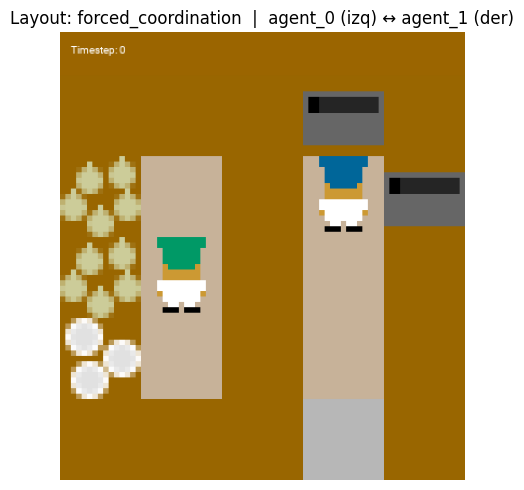

Frame shape: (415, 375, 3)   (H, W, 3 canales RGB)
Para servir una sopa: 3 cebollas pasadas + 1 plato pasado, todo a través del mostrador.


In [14]:
env = TwoAgentOvercooked()
env.reset()
frame = env.render()

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(frame)
ax.set_title(f"Layout: {LAYOUT_NAME}  |  agent_0 (izq) ↔ agent_1 (der)")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Frame shape: {frame.shape}   (H, W, 3 canales RGB)")
print("Para servir una sopa: 3 cebollas pasadas + 1 plato pasado, todo a través del mostrador.")


## 4. Red `ActorCritic` con parameter sharing + crítico centralizado

Aquí materializamos las dos ideas centrales de MAPPO:

### Parameter sharing
**UN solo módulo `ActorCritic`** para los dos agentes. En tiempo de inferencia los dos cocineros hacen forward sobre la misma red — esto fuerza políticas equivalentes (el agente distingue su rol por la información posicional en la observación) y duplica el aprovechamiento muestral.

### Crítico centralizado (CTDE)
- **Actor encoder**: ve solo la observación local de un agente, `(5, 5, 26)`. Convierte → 6 logits.
- **Critic encoder**: ve la observación global, `(5, 5, 52)` (las dos obs apiladas en el canal). Devuelve un único `V(s)`.

Esto es exactamente *Centralised Training, Decentralised Execution*: el crítico (solo usado durante entrenamiento para estimar ventajas) tiene información extra; el actor (usado tanto en train como en deploy) NO. Si mañana quisieras desplegar al agente en un robot, le quitas el crítico y se queda solo el actor descentralizado.

### Arquitectura
Encoder convolucional ligero (2 capas conv 3×3 → MLP), idéntico para actor y crítico salvo por el número de canales de entrada y la cabeza final.


In [ ]:
class ActorCritic(nn.Module):
    """Red Actor-Critic con parameter sharing + crítico centralizado.

    - Actor: obs local (H,W,C) -> 6 logits.
    - Critic: obs global (H,W,2C) -> V escalar.
    Los dos agentes comparten esta MISMA instancia.
    """

    def __init__(self, obs_shape, global_shape, n_actions=NUM_ACTIONS, hidden=128):
        super().__init__()
        H, W, C  = obs_shape           # (5, 5, 26)
        _, _, Cg = global_shape        # (5, 5, 52)

        def encoder(in_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, 32, kernel_size=3),   # 5 -> 3
                nn.ReLU(),
                nn.Conv2d(32, 64, kernel_size=3),      # 3 -> 1
                nn.ReLU(),
                nn.Flatten(),                           # -> 64
                nn.Linear(64, hidden),
                nn.Tanh(),
                nn.Linear(hidden, hidden),
                nn.Tanh(),
            )

        self.actor_encoder  = encoder(C)
        self.critic_encoder = encoder(Cg)
        self.actor_head     = nn.Linear(hidden, n_actions)
        self.critic_head    = nn.Linear(hidden, 1)

    # --- forwards ---
    def _actor_logits(self, obs_local):
        # obs_local: (B, H, W, C) -> conv quiere (B, C, H, W)
        x = obs_local.permute(0, 3, 1, 2)
        return self.actor_head(self.actor_encoder(x))

    def value(self, obs_global):
        x = obs_global.permute(0, 3, 1, 2)
        return self.critic_head(self.critic_encoder(x)).squeeze(-1)

    # --- muestreo en rollout ---
    @torch.no_grad()
    def act(self, obs_local, deterministic=False):
        """Devuelve (action, log_prob, entropy). obs_local: (B,H,W,C)."""
        logits = self._actor_logits(obs_local)
        dist   = Categorical(logits=logits)
        action = logits.argmax(dim=-1) if deterministic else dist.sample()
        return action, dist.log_prob(action), dist.entropy()

    # --- evaluación durante el update ---
    def evaluate(self, obs_local, action):
        """Devuelve (log_prob, entropy) para acciones ya tomadas."""
        logits = self._actor_logits(obs_local)
        dist   = Categorical(logits=logits)
        return dist.log_prob(action), dist.entropy()


# Sanity check: dimensiones y forward
_env_dim = TwoAgentOvercooked()
model = ActorCritic(_env_dim.obs_shape, _env_dim.global_shape).to(DEVICE)
o0, o1 = _env_dim.reset()
ob_t = torch.as_tensor(o0, dtype=torch.float32, device=DEVICE).unsqueeze(0)
gl_t = torch.as_tensor(_env_dim.global_obs(o0, o1), dtype=torch.float32, device=DEVICE).unsqueeze(0)
a, lp, ent = model.act(ob_t)
v          = model.value(gl_t)
print("Modelo:", sum(p.numel() for p in model.parameters()), "parámetros")
print(f"  actor output  -> action={a.item()}  logπ={lp.item():.3f}  H={ent.item():.3f}")
print(f"  critic output -> V={v.item():.3f}")


## 5. Entrenamiento — rollouts, GAE y PPO clip

El bucle de entrenamiento tiene tres bloques claramente identificables:

### A) Recolección de rollouts (`collect_rollout`)
Jugamos `episodes_per_update` episodios completos guardando, para cada paso `t`:

| Campo | Para qué se usa |
|---|---|
| `obs_local[a]` | Reconstruir la política del agente `a` en el update |
| `obs_global` | Re-evaluar `V(s)` en el update |
| `action[a]`, `log_prob_old[a]` | Numerador y denominador del ratio PPO |
| `value` | Baseline para GAE |
| `reward`, `done` | Cómputo de retornos y ventajas |

### B) Ventajas con GAE (`compute_gae`)
Recurrencia hacia atrás:
$$\delta_t = r_t + \gamma V_{t+1}(1-d_t) - V_t, \quad \hat{A}_t = \delta_t + \gamma\lambda(1-d_t)\hat{A}_{t+1}$$
Compromiso sesgo/varianza controlado por `lambda` (0.95 = típico).

### C) Actualización PPO (`ppo_update`)
`K` épocas sobre minibatches; cada minibatch optimiza:
$$\mathcal{L} = -L^{CLIP} + c_v \, \mathcal{L}_V - c_e\, H[\pi]$$
- `L^CLIP`: ratio recortado (núcleo de PPO).
- `L_V`: MSE entre `V` predicho y retorno.
- `H[π]`: bonificación de entropía → exploración.

Con *parameter sharing*: en cada paso tenemos **2 muestras de actor** (una por agente) y **1 muestra de crítico** (estado global compartido). Para mantener el batch coherente, replicamos el `(global_obs, return, advantage)` para los dos agentes — así el update del actor ve 2T muestras y el del crítico también, pero el gradiente del crítico no se duplica artificialmente porque su predicción depende solo de `obs_global` (única por timestep).

> Tiempo aproximado en Colab + T4: **15–25 minutos** para 150 updates.


In [ ]:
import time
from dataclasses import dataclass


# =====================================================================
# Hiperparámetros de MAPPO. Modifica aquí para experimentar.
# =====================================================================
HYPERPARAMS = {
    # Entorno
    "layout_name": LAYOUT_NAME,
    "horizon":     HORIZON,

    # Rollouts
    "episodes_per_update": 8,      # episodios por iteración (8 * 400 = 3200 pasos)
    "num_updates":         150,    # iteraciones totales

    # Optimización
    "lr":               3e-4,
    "num_epochs":       4,         # épocas de PPO por update
    "num_minibatches":  4,         # nº de minibatches por época
    "grad_clip":        0.5,

    # PPO
    "gamma":         0.99,
    "gae_lambda":    0.95,
    "clip_eps":      0.2,
    "vf_coef":       0.5,
    "ent_coef":      0.02,         # ligeramente alto -> incentiva exploración
}


@dataclass
class RolloutBatch:
    """Datos de un rollout, ya planchados a tensores listos para el update.

    Shapes con T = pasos totales y A = nº agentes (=2 aquí):
      obs_local : (T*A, H, W, C)        — duplicado: una vez por agente
      obs_global: (T*A, H, W, 2C)       — duplicado (la misma global para los dos)
      actions   : (T*A,)
      log_probs : (T*A,)                — log π_old
      advantages: (T*A,)                — duplicado (ventaja del equipo)
      returns   : (T*A,)                — duplicado
    """
    obs_local:  torch.Tensor
    obs_global: torch.Tensor
    actions:    torch.Tensor
    log_probs:  torch.Tensor
    advantages: torch.Tensor
    returns:    torch.Tensor


def compute_gae(rewards, values, last_value, gamma, lam):
    """GAE para UN episodio.

    rewards: (T,)            -- recompensas del equipo, paso a paso
    values : (T,)            -- V(s_t) predichos por el crítico
    last_value: float        -- V(s_T) (0 si el episodio terminó, bootstrap si truncó)
    Devuelve (advantages, returns) de shape (T,).
    """
    T = len(rewards)
    advantages = np.zeros(T, dtype=np.float32)
    gae    = 0.0
    next_v = last_value
    for t in reversed(range(T)):
        delta = rewards[t] + gamma * next_v - values[t]
        gae   = delta + gamma * lam * gae
        advantages[t] = gae
        next_v = values[t]
    returns = advantages + values
    return advantages, returns


def collect_rollout(env, model, n_episodes, device=DEVICE):
    """Juega n_episodes episodios. Devuelve RolloutBatch y métricas."""
    model.eval()
    all_OL, all_OG, all_AC, all_LP = [], [], [], []
    all_ADV, all_RET = [], []
    ep_returns, ep_soups = [], []

    for _ in range(n_episodes):
        OL, OG, AC, LP, VL, RW = [], [], [], [], [], []
        o0, o1 = env.reset()
        ep_r, ep_s = 0.0, 0
        done = False
        for t in range(env.horizon):
            ob_t = torch.as_tensor(np.stack([o0, o1]),               dtype=torch.float32, device=device)
            gl_t = torch.as_tensor(env.global_obs(o0, o1),           dtype=torch.float32, device=device).unsqueeze(0)

            a, lp, _ = model.act(ob_t)              # (2,), (2,), (2,)
            v        = model.value(gl_t).item()     # escalar

            o0_n, o1_n, r, done, info = env.step(a[0].item(), a[1].item())
            ep_r += r
            ep_s += int(round(info["sparse_reward"] / 20.0))

            OL.append(np.stack([o0, o1]))
            OG.append(env.global_obs(o0, o1))
            AC.append(a.cpu().numpy())
            LP.append(lp.cpu().numpy())
            VL.append(v)
            RW.append(r)

            o0, o1 = o0_n, o1_n
            if done: break

        # Bootstrap del último valor: 0 si el episodio terminó (Overcooked siempre
        # devuelve done=True al alcanzar el horizonte), si no, V(s_final).
        if done:
            last_v = 0.0
        else:
            gl_t   = torch.as_tensor(env.global_obs(o0, o1), dtype=torch.float32, device=device).unsqueeze(0)
            last_v = model.value(gl_t).item()

        adv, ret = compute_gae(np.array(RW), np.array(VL), last_v,
                               HYPERPARAMS["gamma"], HYPERPARAMS["gae_lambda"])
        all_OL.extend(OL); all_OG.extend(OG); all_AC.extend(AC); all_LP.extend(LP)
        all_ADV.extend(adv); all_RET.extend(ret)
        ep_returns.append(ep_r)
        ep_soups.append(ep_s)

    # Normalizar ventajas a nivel batch (truco estándar de PPO)
    adv_arr = np.asarray(all_ADV, dtype=np.float32)
    adv_arr = (adv_arr - adv_arr.mean()) / (adv_arr.std() + 1e-8)

    # Apilar y duplicar para parameter sharing (2 muestras de actor por paso)
    OL = np.stack(all_OL)                # (T, 2, H, W, C)
    OG = np.stack(all_OG)                # (T, H, W, 2C)
    AC = np.stack(all_AC)                # (T, 2)
    LP = np.stack(all_LP)                # (T, 2)
    T  = OL.shape[0]

    batch = RolloutBatch(
        obs_local  = torch.as_tensor(OL.reshape(T*2, *OL.shape[2:]), dtype=torch.float32, device=device),
        obs_global = torch.as_tensor(np.repeat(OG, 2, axis=0),        dtype=torch.float32, device=device),
        actions    = torch.as_tensor(AC.reshape(T*2),                 dtype=torch.long,    device=device),
        log_probs  = torch.as_tensor(LP.reshape(T*2),                 dtype=torch.float32, device=device),
        advantages = torch.as_tensor(np.repeat(adv_arr, 2),           dtype=torch.float32, device=device),
        returns    = torch.as_tensor(np.repeat(all_RET, 2),           dtype=torch.float32, device=device),
    )
    return batch, ep_returns, ep_soups


def ppo_update(model, optimizer, batch: RolloutBatch, hp):
    """K épocas de PPO sobre el batch. Devuelve estadísticas medias."""
    model.train()
    N  = batch.actions.shape[0]
    mb = N // hp["num_minibatches"]
    idxs = np.arange(N)

    stats = {"policy_loss": [], "value_loss": [], "entropy": [], "approx_kl": []}
    for _ in range(hp["num_epochs"]):
        np.random.shuffle(idxs)
        for s in range(0, N, mb):
            mb_idx = idxs[s:s+mb]
            mb_idx_t = torch.as_tensor(mb_idx, dtype=torch.long, device=batch.actions.device)

            ol  = batch.obs_local.index_select(0, mb_idx_t)
            og  = batch.obs_global.index_select(0, mb_idx_t)
            ac  = batch.actions.index_select(0, mb_idx_t)
            lpo = batch.log_probs.index_select(0, mb_idx_t)
            adv = batch.advantages.index_select(0, mb_idx_t)
            ret = batch.returns.index_select(0, mb_idx_t)

            lp_new, ent = model.evaluate(ol, ac)
            v_new       = model.value(og)

            # ---- PPO clip loss ----
            ratio = torch.exp(lp_new - lpo)
            unclipped = ratio * adv
            clipped   = torch.clamp(ratio, 1 - hp["clip_eps"], 1 + hp["clip_eps"]) * adv
            policy_loss = -torch.min(unclipped, clipped).mean()

            # ---- value loss + entropy bonus ----
            value_loss   = 0.5 * (v_new - ret).pow(2).mean()
            entropy_loss = -ent.mean()
            loss = policy_loss + hp["vf_coef"] * value_loss + hp["ent_coef"] * entropy_loss

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), hp["grad_clip"])
            optimizer.step()

            with torch.no_grad():
                approx_kl = (lpo - lp_new).mean().item()
            stats["policy_loss"].append(policy_loss.item())
            stats["value_loss"].append(value_loss.item())
            stats["entropy"].append(ent.mean().item())
            stats["approx_kl"].append(approx_kl)
    return {k: float(np.mean(v)) for k, v in stats.items()}


# =====================================================================
# Bucle de entrenamiento
# =====================================================================
hp = HYPERPARAMS
env = TwoAgentOvercooked(hp["layout_name"], hp["horizon"])
model = ActorCritic(env.obs_shape, env.global_shape).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=hp["lr"])

print(f"Entrenando MAPPO durante {hp['num_updates']} updates "
      f"({hp['episodes_per_update']} episodios/update).\n")
print(f"{'upd':>4} | {'ep_rew':>8} | {'sopas':>6} | {'π_loss':>8} | "
      f"{'V_loss':>8} | {'H':>6} | {'KL':>7} | {'t/upd':>6}")
print("-" * 72)

learning_curve = []
t0 = time.time()
for upd in range(1, hp["num_updates"] + 1):
    t_upd = time.time()
    batch, ep_rets, ep_soups = collect_rollout(env, model, hp["episodes_per_update"])
    s = ppo_update(model, optimizer, batch, hp)
    dt = time.time() - t_upd

    rew_mean  = float(np.mean(ep_rets))
    soup_mean = float(np.mean(ep_soups))
    learning_curve.append({"upd": upd, "reward": rew_mean, "soups": soup_mean,
                            "policy_loss": s["policy_loss"], "value_loss": s["value_loss"],
                            "entropy": s["entropy"], "approx_kl": s["approx_kl"]})
    if upd % 5 == 0 or upd == 1:
        print(f"{upd:>4} | {rew_mean:>8.2f} | {soup_mean:>6.2f} | "
              f"{s['policy_loss']:>8.4f} | {s['value_loss']:>8.3f} | "
              f"{s['entropy']:>6.3f} | {s['approx_kl']:>+7.4f} | {dt:>5.1f}s")

print(f"\nEntrenamiento completado en {(time.time()-t0)/60:.1f} min.")

# Guardar pesos
ckpt_path = "mappo_actorcritic.pt"
torch.save(model.state_dict(), ckpt_path)
print(f"Pesos guardados en {ckpt_path}")

# Curva de aprendizaje
upds      = [x["upd"]    for x in learning_curve]
rewards   = [x["reward"] for x in learning_curve]
soups     = [x["soups"]  for x in learning_curve]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(upds, rewards, color="tab:blue", linewidth=2)
ax1.set_title("Recompensa media por episodio (shaping incl.)")
ax1.set_xlabel("Update"); ax1.set_ylabel("Reward"); ax1.grid(alpha=0.3)
ax2.plot(upds, soups, color="tab:orange", linewidth=2)
ax2.set_title("Sopas entregadas por episodio (cooperación efectiva)")
ax2.set_xlabel("Update"); ax2.set_ylabel("Sopas"); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Evaluación cuantitativa

Comparamos contra la baseline aleatoria. Métricas:

- **Reward total medio** (shaping incluido). Da una idea general de eficiencia.
- **Sopas entregadas** (señal sparse +20). Es **la** métrica de cooperación: en `forced_coordination` la baseline aleatoria entrega 0 sopas porque entregar requiere coordinación deliberada.
- Desviación estándar entre episodios.

`policy_fn` envuelve nuestro `model` para usarlo en modo determinista (acción más probable). Esta es la **ejecución descentralizada**: cada agente decide solo con su observación local — el crítico ya no participa.


In [ ]:
def make_policy_fn(model, deterministic=True):
    """Devuelve callable (o0, o1) -> (a0, a1) usando el actor entrenado."""
    def policy_fn(o0, o1):
        ob = torch.as_tensor(np.stack([o0, o1]), dtype=torch.float32, device=DEVICE)
        a, _, _ = model.act(ob, deterministic=deterministic)
        return int(a[0].item()), int(a[1].item())
    return policy_fn


def evaluate(policy_fn, n_episodes=10, layout_name=HYPERPARAMS["layout_name"]):
    env = TwoAgentOvercooked(layout_name, HORIZON)
    rewards, soups = [], []
    for ep in range(n_episodes):
        o0, o1 = env.reset()
        total_r, total_s = 0.0, 0
        for t in range(env.horizon):
            if policy_fn is None:
                a0, a1 = np.random.randint(NUM_ACTIONS), np.random.randint(NUM_ACTIONS)
            else:
                a0, a1 = policy_fn(o0, o1)
            o0, o1, r, done, info = env.step(a0, a1)
            total_r += r
            total_s += int(round(info["sparse_reward"] / 20.0))
            if done: break
        rewards.append(total_r)
        soups.append(total_s)
    return {
        "reward_mean": float(np.mean(rewards)),
        "reward_std":  float(np.std(rewards)),
        "soups_mean":  float(np.mean(soups)),
        "soups_std":   float(np.std(soups)),
    }


trained_policy_fn = make_policy_fn(model, deterministic=True)
rnd   = evaluate(None,              n_episodes=10)
mappo = evaluate(trained_policy_fn, n_episodes=10)

print("Resultados sobre 10 episodios:")
print(f"{'':<10} {'reward':>17} {'sopas/ep':>16}")
print("-" * 45)
print(f"{'Aleatoria':<10} {rnd['reward_mean']:>8.2f} ± {rnd['reward_std']:>5.2f}  "
      f"{rnd['soups_mean']:>6.2f} ± {rnd['soups_std']:.2f}")
print(f"{'MAPPO':<10} {mappo['reward_mean']:>8.2f} ± {mappo['reward_std']:>5.2f}  "
      f"{mappo['soups_mean']:>6.2f} ± {mappo['soups_std']:.2f}")
print()
if mappo["soups_mean"] > rnd["soups_mean"]:
    delta = mappo["soups_mean"] - rnd["soups_mean"]
    print(f">>> MAPPO entrega {mappo['soups_mean']:.1f} sopas/episodio vs {rnd['soups_mean']:.1f} de la baseline.")
    print(f">>> Esa diferencia (+{delta:.1f}) ES la cooperación emergente: ningún agente puede entregar solo.")


## 7. Renderizado a MP4 — comparación visual

Generamos **dos vídeos** con la misma semilla:

1. `overcooked_random.mp4` — baseline aleatoria (los cocineros se mueven sin sentido).
2. `overcooked_mappo.mp4` — política entrenada (deberías verlos pasarse cebollas y servir sopas).

---

### Conclusiones — qué hemos visto

- **Implementación completa del MAS** sin frameworks "caja negra": cada componente (rollouts, GAE, clip loss, parameter sharing, centralised critic) es código nuestro que puedes leer y modificar.
- **MAPPO en acción**: PPO multiagente con CTDE. El crítico (centralizado) usa la observación global para reducir varianza durante el entrenamiento; el actor (descentralizado, compartido) decide con solo su observación local.
- **Coordinación emergente** en `forced_coordination`: nunca le dijimos a los agentes *cómo* cooperar. El reward shaping + la recompensa global compartida + la centralización del crítico bastan para que aprendan el protocolo `cebolla → mostrador → olla → plato → servir` por sí solos.

### Lo que sí o sí está reflejado en este notebook
- *Sistemas multiagente cooperativos*: dos agentes, mismo reward, observación parcial cada uno.
- *Parameter sharing*: una sola red para los dos agentes.
- *CTDE (Centralised Training, Decentralised Execution)*: crítico global, actor local.
- *PPO clip + GAE + entropy bonus*: la receta clásica de PPO, escrita a mano.


In [ ]:
def rollout_to_mp4(policy_fn=None, output_path="overcooked_rollout.mp4",
                   fps=8, layout_name=HYPERPARAMS["layout_name"]):
    env = TwoAgentOvercooked(layout_name, HORIZON)
    o0, o1 = env.reset()
    frames = [env.render()]
    total_r, total_s = 0.0, 0
    for t in range(env.horizon):
        if policy_fn is None:
            a0, a1 = np.random.randint(NUM_ACTIONS), np.random.randint(NUM_ACTIONS)
        else:
            a0, a1 = policy_fn(o0, o1)
        o0, o1, r, done, info = env.step(a0, a1)
        total_r += r
        total_s += int(round(info["sparse_reward"] / 20.0))
        frames.append(env.render())
        if done: break

    writer = imageio.get_writer(output_path, fps=fps, codec="libx264",
                                quality=8, macro_block_size=1)
    for f in frames:
        writer.append_data(f.astype(np.uint8))
    writer.close()
    print(f"  {os.path.basename(output_path):<22} frames={len(frames):>3}  "
          f"pasos={t+1:>3}  reward={total_r:6.2f}  sopas={total_s}")
    return output_path


print("Generando vídeos de comparación...\n")
rollout_to_mp4(policy_fn=None,              output_path="overcooked_random.mp4")
rollout_to_mp4(policy_fn=trained_policy_fn, output_path="overcooked_mappo.mp4")

print("\nListo. Abre los dos MP4 lado a lado para comparar el comportamiento:")
print("- overcooked_random.mp4 : cocineros sin coordinación (baseline)")
print("- overcooked_mappo.mp4  : cocineros entrenados con MAPPO -> cooperación emergente")
